# Fase 3 — Os dados

**Objetivo.** Montar e documentar a base que todas as estratégias do projeto usam: preços diários ajustados de ações brasileiras, o CDI como taxa livre de risco e os fatores do NEFIN como referência de mercado.
Este notebook não inventa dado novo — ele refaz, na ordem em que a coisa acontece, a passagem do que foi baixado para o que ficou gravado em `data/processed/`, mostrando o que entrou, o que foi jogado fora e por quê.
Quem ler daqui até o fim deve terminar sabendo em que números pode confiar e, principalmente, em quais não pode.

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
PROC = RAIZ / "data" / "processed"
sys.path.insert(0, str(RAIZ / "src"))

from moq import data

# sem isso os log.warning de dentro do moq não aparecem formatados
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)
plt.rcParams["figure.figsize"] = (10, 4)

print("raiz:", RAIZ)

raiz: /home/marialuisa/finance/mini-open-quant


## 1. Universo

**Os tickers.** Trinta ações da B3, escolhidas na mão: as maiores e mais negociadas do Ibovespa, com alguns setores repetidos de propósito (dois bancos grandes, duas Petrobras, duas elétricas) porque a Fase 4 precisa de pares parecidos para a estratégia de cointegração.
Não é um índice nem um filtro automático — é uma lista escrita por mim, e a seção de limitações explica o preço disso.

**A data inicial: 01/01/2012.** Queria uma janela longa o bastante para conter mais de um regime de mercado, e 2012 é o começo natural dessa história no Brasil: a expansão de 2012–2014, a recessão e a Lava-Jato a partir de 2015, a recuperação de 2016–2019, o crash da covid em 2020 e os ciclos de juros que vieram depois.
Puxar mais para trás traria a crise de 2008, mas também traria muito mais empresa com série incompleta ou que nem existia — e o Yahoo fica visivelmente pior quanto mais antigo o dado.

**O que sai e por quê.** A limpeza tem uma regra só, em `moq.data.clean_prices`: ativo com mais de 5% dos pregões sem preço (`MAX_MISSING_FRACTION`) é removido inteiro; buracos curtos, de até 3 dias (`FFILL_LIMIT`), são preenchidos com o último preço.
As células abaixo mostram quem foi removido e por qual dos dois motivos.

In [2]:
TICKERS = ["PETR4","PETR3","VALE3","ITUB4","BBDC4","BBAS3","ABEV3","WEGE3",
           "B3SA3","RENT3","SUZB3","ELET3","PRIO3","RADL3","EQTL3","BPAC11",
           "ITSA4","LREN3","HAPV3","GGBR4","JBSS3","RAIL3","VIVT3","CSAN3",
           "EMBR3","TOTS3","CMIG4","BBSE3","ENEV3","SBSP3"]
INICIO = "2012-01-01"

# o download já foi feito e gravado pelo notebook 03; só baixo de novo se o arquivo não existir
# (data/raw/ está no .gitignore, então num clone limpo cai no else)
caminho_bruto = RAW / "precos_brutos.parquet"
if caminho_bruto.exists():
    prices = pd.read_parquet(caminho_bruto)
    print("lido de", caminho_bruto.relative_to(RAIZ))
else:
    import yfinance as yf

    # auto_adjust=True: o fechamento já vem descontado de dividendos, JCP e desdobramentos
    bruto = yf.download([t + ".SA" for t in TICKERS], start=INICIO, auto_adjust=True, progress=False)
    prices = bruto["Close"].copy()
    prices.columns = [c.replace(".SA", "") for c in prices.columns]
    prices.index = pd.DatetimeIndex(prices.index).tz_localize(None)
    RAW.mkdir(parents=True, exist_ok=True)
    prices.to_parquet(caminho_bruto)
    print("baixado do Yahoo e gravado em", caminho_bruto.relative_to(RAIZ))

print(f"{prices.shape[1]} tickers pedidos | {len(prices)} pregões | "
      f"{prices.index.min().date()} → {prices.index.max().date()}")

lido de data/raw/precos_brutos.parquet
30 tickers pedidos | 3653 pregões | 2012-01-02 → 2026-09-14


In [3]:
# fração de pregões sem preço, por ativo — é essa coluna que decide quem fica
frac = (prices.isna().mean() * 100).sort_values(ascending=False)
frac[frac > 0].round(1).to_frame("% de pregões sem preço")

,% de pregões sem preço
ELET3,100.0
EMBR3,100.0
JBSS3,100.0
HAPV3,43.0
BPAC11,34.9
RAIL3,22.0
BBSE3,8.9


In [4]:
# primeiro pregão com preço de cada candidato a remoção: separa "não existia" de "sumiu"
suspeitos = frac[frac > 5].index
pd.DataFrame(
    {"primeiro preço": [prices[t].first_valid_index() for t in suspeitos],
     "% ausente": frac[suspeitos].round(1).values},
    index=suspeitos,
)

,primeiro preço,% ausente
ELET3,NaT,100.0
EMBR3,NaT,100.0
JBSS3,NaT,100.0
HAPV3,2018-04-26,43.0
BPAC11,2017-02-24,34.9
RAIL3,2015-04-02,22.0
BBSE3,2013-04-29,8.9


In [5]:
data.validate_prices(prices)  # ordem do índice, datas duplicadas, preço não positivo
prices_clean = data.clean_prices(prices)

print(f"\n{prices.shape[1]} → {prices_clean.shape[1]} ativos | NaN restante: {int(prices_clean.isna().sum().sum())}")
print(sorted(prices_clean.columns))

WARNING moq.data: ativo BBSE3 removido: 8.9% ausente


WARNING moq.data: ativo BPAC11 removido: 34.9% ausente


WARNING moq.data: ativo ELET3 removido: 100.0% ausente


WARNING moq.data: ativo EMBR3 removido: 100.0% ausente


WARNING moq.data: ativo HAPV3 removido: 43.0% ausente


WARNING moq.data: ativo JBSS3 removido: 100.0% ausente


WARNING moq.data: ativo RAIL3 removido: 22.0% ausente



30 → 23 ativos | NaN restante: 0
['ABEV3', 'B3SA3', 'BBAS3', 'BBDC4', 'CMIG4', 'CSAN3', 'ENEV3', 'EQTL3', 'GGBR4', 'ITSA4', 'ITUB4', 'LREN3', 'PETR3', 'PETR4', 'PRIO3', 'RADL3', 'RENT3', 'SBSP3', 'SUZB3', 'TOTS3', 'VALE3', 'VIVT3', 'WEGE3']


**Lendo o que saiu: 30 → 23.** As remoções são de dois tipos, e só um deles é problema.

- **Não veio nada (100% ausente): ELET3, EMBR3, JBSS3.** O Yahoo devolveu a série inteira vazia, com a mensagem `possibly delisted; no timezone found`. Isso é diagnóstico do provedor, não prova de que o papel saiu da bolsa — não fui atrás de confirmar caso a caso. De qualquer forma, sem dado nenhum não há o que aproveitar.
- **Existiam, mas não desde 2012: BBSE3 (abriu em abr/2013), RAIL3 (abr/2015), BPAC11 (fev/2017), HAPV3 (abr/2018).** Aqui o "ausente" não é falha de dado: é ação que ainda não era negociada. A regra dos 5% derruba as quatro porque 2012 é o começo da janela; se o universo começasse em 2019, todas ficariam.

Sobram **23 ativos com série completa** — depois da limpeza não resta um único NaN, o que quer dizer que nenhum dos 23 tinha nem os buraquinhos de até 3 dias que o `ffill` cobriria.
Esse é o universo que a Fase 4 usa, e é o que está gravado em `data/processed/precos.parquet`.

## 2. Cobertura: quantos ativos válidos por dia

O gráfico serve para responder uma pergunta só: em algum momento da janela a carteira teria ficado sem ativos para escolher?
A linha cinza é o que foi baixado (os 30 menos os 3 vazios), a colorida é o que sobrou depois da limpeza.

limpo: mínimo 23 e máximo 23 ativos por dia, em 3653 pregões


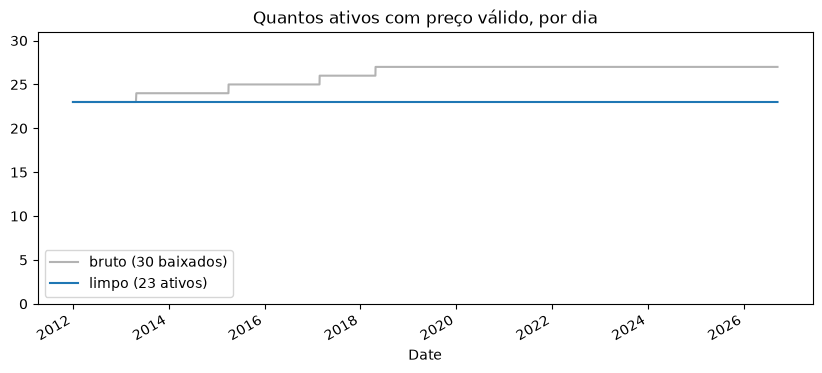

In [6]:
validos = prices_clean.notna().sum(axis=1)

ax = prices.notna().sum(axis=1).plot(color="0.7", label=f"bruto ({prices.shape[1]} baixados)")
validos.plot(ax=ax, label=f"limpo ({prices_clean.shape[1]} ativos)")
ax.set_title("Quantos ativos com preço válido, por dia")
ax.set_ylim(0, prices.shape[1] + 1)
ax.legend()

print(f"limpo: mínimo {validos.min()} e máximo {validos.max()} ativos por dia, em {len(validos)} pregões")

**O que eu vejo.** A linha do limpo é uma reta em 23, todo dia, do primeiro ao último pregão — nenhuma janela do backtest terá menos ativos que outra, e nenhuma estratégia vai olhar para um dia em que o universo encolheu.

A reta é boa e ruim ao mesmo tempo. Boa porque elimina uma fonte de erro chata: carteira que muda de tamanho sozinha, peso que explode porque sobraram três ativos naquele mês. Ruim porque essa estabilidade foi comprada jogando fora tudo que entrou depois de 2012 — a escada da linha cinza, que sobe de 23 para 27 conforme as empresas abriam capital, é exatamente a parte da realidade que o universo fixo não tem.
Um universo honesto **deveria** mudar de tamanho ao longo do tempo; o meu não muda porque foi recortado para não mudar.

## 3. CDI: a conta de 2023 que prova a unidade

O CDI vem da série 12 do SGS (Banco Central), que devolve a taxa **em porcentagem ao dia** — algo como `0,041`, que significa 0,041% e não 4,1%.
Tudo no projeto trabalha em decimal, então `moq.data.fetch_cdi` divide por 100 na saída. Errar isso passa despercebido em cima de um dia e destrói qualquer backtest em cima de um ano, então a checagem é acumular 2023 e comparar com um número que eu já sei de cor.

In [7]:
# o SGS recusa consulta diária com janela > 10 anos; fetch_cdi baixa em blocos de 5 anos e concatena
cdi = data.fetch_cdi(INICIO)
print(cdi.head(3))
print("período:", cdi.index.min().date(), "→", cdi.index.max().date(), "| dias:", len(cdi))

ano = cdi["2023"]
acumulado = (1 + ano).prod() - 1
print(f"\nCDI acumulado em 2023 ({len(ano)} dias úteis): {acumulado:.2%}")
print(f"mesma conta se a série ainda estivesse em %: {(1 + ano * 100).prod() - 1:,.0f} vezes o capital")

INFO httpx: HTTP Request: GET https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01%2F01%2F2012&dataFinal=31%2F12%2F2016 "HTTP/1.1 200 OK"


INFO httpx: HTTP Request: GET https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01%2F01%2F2017&dataFinal=31%2F12%2F2021 "HTTP/1.1 200 OK"


INFO httpx: HTTP Request: GET https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01%2F01%2F2022&dataFinal=17%2F09%2F2026 "HTTP/1.1 200 OK"


Date
2012-01-02    0.00041
2012-01-03    0.00041
2012-01-04    0.00041
Name: cdi, dtype: float64
período: 2012-01-02 → 2026-09-16 | dias: 3694

CDI acumulado em 2023 (249 dias úteis): 13.04%
mesma conta se a série ainda estivesse em %: 157,453 vezes o capital


In [8]:
# o CDI que as estratégias usam é este, no calendário dos preços (dia sem CDI vira 0)
cdi_alinhado = data.align_cdi(cdi, prices_clean)
print("mesmo calendário dos preços:", cdi_alinhado.index.equals(prices_clean.index))
print(f"acumulado de 2023 já alinhado: {(1 + cdi_alinhado['2023']).prod() - 1:.2%}")

WARNING moq.data: CDI ausente em 6 pregões; preenchido com 0


mesmo calendário dos preços: True
acumulado de 2023 já alinhado: 12.99%


**Por que isso prova a unidade.** O CDI acumulado de 2023 foi **13,04%** — é o número divulgado, dá para conferir em qualquer lugar. A série em decimal reproduz exatamente isso.
Se ela ainda estivesse em porcentagem, a mesma conta devolveria algo como 157 mil vezes o capital, um absurdo que não tem como passar batido. Um fator 100 errado na taxa livre de risco viraria um Sharpe negativo em qualquer estratégia, e essa linha é o que impede isso de entrar silenciosamente.

**Uma diferença pequena que vale registrar:** alinhado ao calendário da B3, 2023 dá **12,99%**, 0,05 p.p. a menos. A causa é o encaixe dos dois calendários, nas duas direções: o CDI rende em 47 dias da amostra em que não houve pregão (feriados municipais de São Paulo, 24/12, 31/12) e esses dias somem no `reindex`; e em 6 pregões de 2017 o preço existe mas o CDI não foi publicado, e o `align_cdi` preenche com zero — é o aviso que aparece acima. Em 2023 a diferença inteira é um dia só: 29/12, que rendeu 0,044% com a bolsa fechada.
Os dois efeitos empurram para o mesmo lado, o de subestimar o CDI, ou seja, comparar uma estratégia com essa série é levemente generoso com a estratégia. Não corrigi; só não quero descobrir isso de novo daqui a três meses.


## 4. NEFIN: o fator de mercado

Os fatores do [NEFIN/USP](https://nefin.com.br) são o padrão acadêmico para o mercado brasileiro: mercado (`Rm − Rf`, aqui renomeado `MKT`), tamanho (`SMB`), valor (`HML`) e momentum (`WML`), em retorno diário decimal.
Eles não entram em nenhuma estratégia — servem como régua: quando uma carteira minha ganhar dinheiro, quero saber quanto disso é só o mercado subindo.

In [9]:
# o NEFIN mudou o formato: antes era um .xls por fator com colunas year/month/day,
# agora é um CSV único com coluna Date e todos os fatores juntos
def ler_fatores(caminho):
    df = pd.read_csv(caminho, index_col=0)  # 1ª coluna é só um contador
    df.index = pd.to_datetime(df["Date"])
    df.index.name = "Date"
    return df[["Rm_minus_Rf", "SMB", "HML", "WML"]].rename(columns={"Rm_minus_Rf": "MKT"})


fatores = ler_fatores(RAW / "nefin" / "nefin_factors.csv")
print("período:", fatores.index.min().date(), "→", fatores.index.max().date(), "| dias:", len(fatores))
print("ordenado:", fatores.index.is_monotonic_increasing, "| duplicadas:", fatores.index.has_duplicates,
      "| NaN:", int(fatores.isna().sum().sum()))

# sanidade da unidade: em decimal o retorno diário típico é da ordem de 0,01 (em % seria ~1)
print("\nmediana de |retorno diário| por fator:")
print(fatores.abs().median().round(4))

período: 2001-01-02 → 2026-07-03 | dias: 6321
ordenado: True | duplicadas: False | NaN: 0

mediana de |retorno diário| por fator:
MKT    0.0080
SMB    0.0060
HML    0.0051
WML    0.0058
dtype: float64


acumulado de 2012-01-02 a 2026-07-03: -7.1%
pregões de preço sem fator no fim da amostra: 59


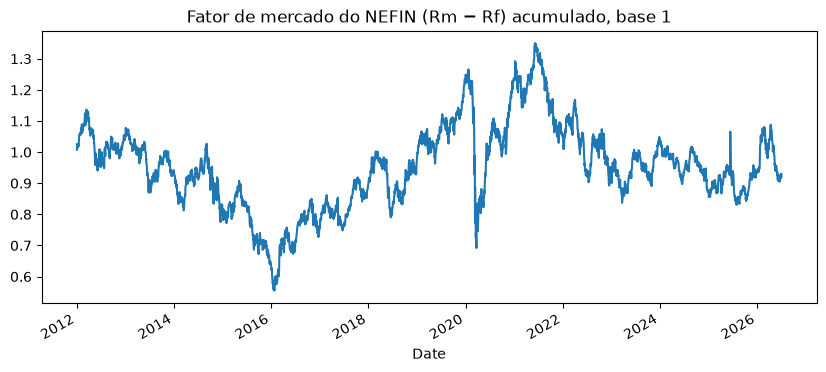

In [10]:
mkt = fatores["MKT"][INICIO:]
(1 + mkt).cumprod().plot(title="Fator de mercado do NEFIN (Rm − Rf) acumulado, base 1")
print(f"acumulado de {mkt.index.min().date()} a {mkt.index.max().date()}: {(1 + mkt).prod() - 1:.1%}")
print("pregões de preço sem fator no fim da amostra:",
      int(fatores.reindex(prices_clean.index).isna().any(axis=1).sum()))

**O que eu vejo.** De 2012 até hoje o fator de mercado acumula **−7%**, e o caminho até esse zero foi violento: queda de 44% até o começo de 2016, recuperação longa até o pico de 2021, o buraco vertical da covid em março de 2020 e um vaivém sem direção desde então. Não é o Ibovespa caindo: `MKT` é o retorno do mercado **menos** a taxa livre de risco, então isso quer dizer que, em quatorze anos, tomar risco em bolsa no Brasil não pagou nada acima do CDI — pagou menos.

Duas consequências diretas para o resto do projeto: (1) o CDI é um benchmark duro, não uma formalidade, e qualquer estratégia aqui precisa vencer ele, não o Ibovespa; (2) uma carteira comprada que renda bem nesse período está rendendo por seleção de ativos, não por exposição ao mercado — e é aí que o viés de sobrevivência da próxima seção morde.

Detalhe operacional: o arquivo do NEFIN termina em **03/07/2026**, enquanto os preços vão até setembro. São **59 pregões no fim da amostra sem fator** (as 236 células vazias de `fatores.parquet`, 59 × 4). Qualquer regressão contra fatores precisa parar em julho ou baixar o CSV atualizado.

## 5. Limitações

As três coisas abaixo não são bugs a corrigir num commit — são propriedades desta base de dados. Enquanto elas estiverem valendo, todo resultado do projeto tem que ser lido com elas em mente.

### Viés de sobrevivência

A lista de 30 tickers foi escrita agora, olhando para quem é grande e líquido **hoje**. Empresa que quebrou, foi comprada, virou penny stock ou simplesmente saiu do índice ao longo desses quatorze anos nunca teve chance de entrar no universo — e é exatamente esse grupo que teria dado prejuízo.
Ou seja: informação do futuro (quem sobreviveu) foi usada para escolher o passado. Qualquer backtest rodado aqui vai ser otimista, e o erro tem sempre o mesmo sinal. Não é ruído que some com mais dados, não sai com validação cruzada, não melhora ajustando parâmetro: o problema está na amostra, não no modelo. Estratégias de seleção de ações, como o momentum da Fase 4, são as mais contaminadas, porque parte do "sinal" é só a lista já ter excluído os perdedores.

**Solução futura:** o COTAHIST da B3 traz o histórico de negociação de todos os papéis de cada ano, inclusive os que deixaram de existir. Com ele dá para reconstruir o universo *como ele era* em cada data de rebalanceamento, em vez de congelar a foto de hoje. Até isso acontecer, os retornos deste projeto são um teto, não uma expectativa.

### Ajuste de proventos

Os preços vêm do Yahoo com `auto_adjust=True`, então dividendos, JCP, desdobramentos e grupamentos já entram descontados no fechamento — é o que permite tratar a variação do preço como retorno total, sem somar provento por fora.
A conta, porém, é do Yahoo, e eu não tenho como auditá-la: não existe aqui um arquivo de proventos da B3 para bater papel a papel. Quando o ajuste falha, o sintoma é um retorno diário absurdo, e foi assim que os casos estranhos apareceram (o filtro de `|retorno| > 50%` no notebook 03) e foram removidos **na mão**.
"Na mão" quer dizer sem regra escrita, sem registro automático e sem garantia de reprodutibilidade: o Yahoo reescreve histórico quando corrige uma série, então o mesmo download amanhã pode trazer números diferentes dos que estão em `data/processed/` hoje. Nada aqui depende de dado fundamentalista, o que limita o estrago, mas o retorno de um papel que passou por evento societário mal ajustado entra errado no backtest e ninguém avisa.

### Liquidez

Esta base tem preço de fechamento e mais nada. Não tem volume financeiro, não tem spread de compra e venda, não tem livro de ofertas.
Então nada aqui garante que dava para comprar ou vender esses papéis, no volume que uma estratégia pediria, pelo preço que aparece na tabela. Para blue chips e posições pequenas a distância entre os dois provavelmente é pequena — mas duas coisas continuam invisíveis: o impacto de mercado (ordem grande anda contra o próprio preço) e os períodos específicos em que um papel secou, justamente nos dias de estresse em que a estratégia mais quer negociar.
As estratégias de giro alto são as mais expostas: a reversão à média da Fase 4 gira a carteira quase todo dia e pagaria spread em todas as pontas, o que pode consumir o retorno inteiro. Enquanto não entrarem volume diário e um modelo de custo de transação, os retornos brutos deste projeto são limite superior, não resultado.